# 📈 StockLens — Stock Price Analysis

**Data Source:** Yahoo Finance (live, via `yfinance`)  
**Stocks Analysed:** Apple (AAPL), Microsoft (MSFT), Tesla (TSLA), Amazon (AMZN), Google (GOOGL)  
**Period:** 2020 – 2024  
**Goal:** Analyse closing price trends, moving averages, daily returns, volatility and cross-stock correlations.

---

## 1. Import Libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

COLORS = ['#3b82f6', '#f59e0b', '#10b981', '#ef4444', '#8b5cf6']
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Download Live Stock Data

In [2]:
TICKERS = ['AAPL', 'MSFT', 'TSLA', 'AMZN', 'GOOGL']
START   = '2020-01-01'
END     = '2024-12-31'

raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True)
df  = raw['Close'].copy()
df.dropna(inplace=True)

print(f'Shape: {df.shape}')
print(f'Period: {df.index[0].date()} → {df.index[-1].date()}')
df.head()

[                       0%                       ]

[*******************   40%                       ]  2 of 5 completed

[**********************60%****                   ]  3 of 5 completed

[**********************80%*************          ]  4 of 5 completed

[*********************100%***********************]  5 of 5 completed

Shape: (1257, 5)
Period: 2020-01-02 → 2024-12-30


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-01-02,72.333878,94.900497,67.873024,152.158401,28.684000
2020-01-03,71.630646,93.748497,67.517960,150.263779,29.534000
2020-01-06,72.201401,95.143997,69.317596,150.652176,30.102667
2020-01-07,71.861855,95.343002,69.183701,149.278564,31.270666
2020-01-08,73.017838,94.598503,69.676125,151.656326,32.809334


## 3. Closing Price Trends

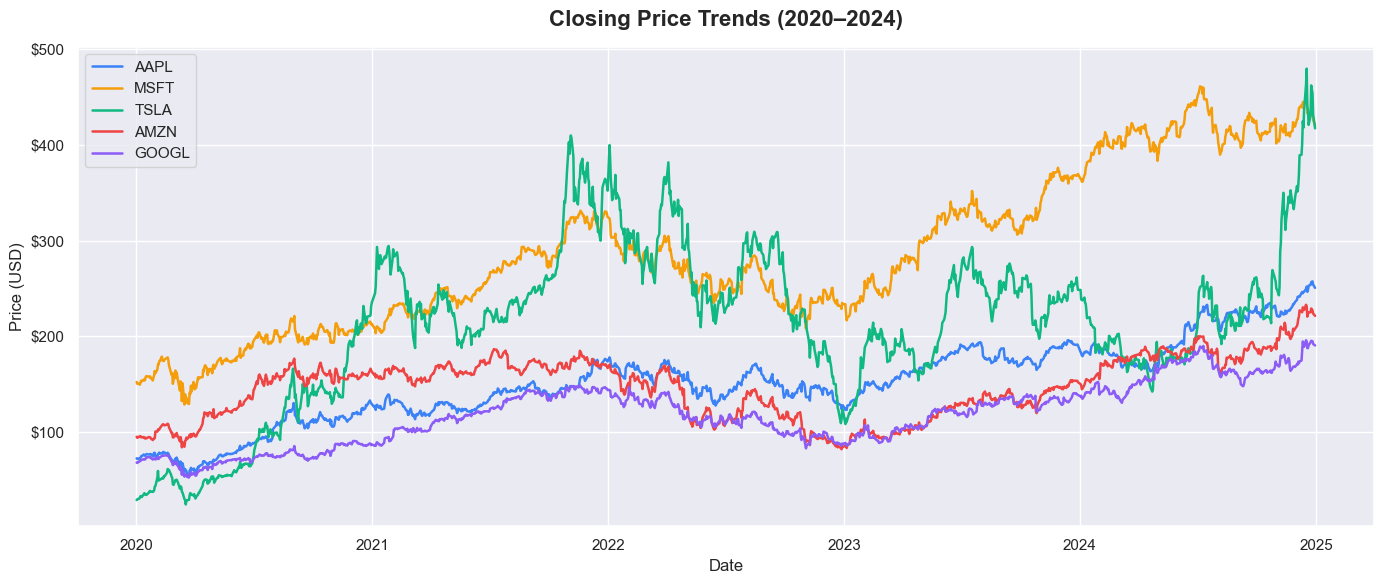

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))
for ticker, color in zip(TICKERS, COLORS):
    ax.plot(df.index, df[ticker], label=ticker, color=color, linewidth=1.8)

ax.set_title('Closing Price Trends (2020–2024)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('outputs/closing_prices.png', dpi=150)
plt.show()

## 4. Normalised Performance (Base = 100)

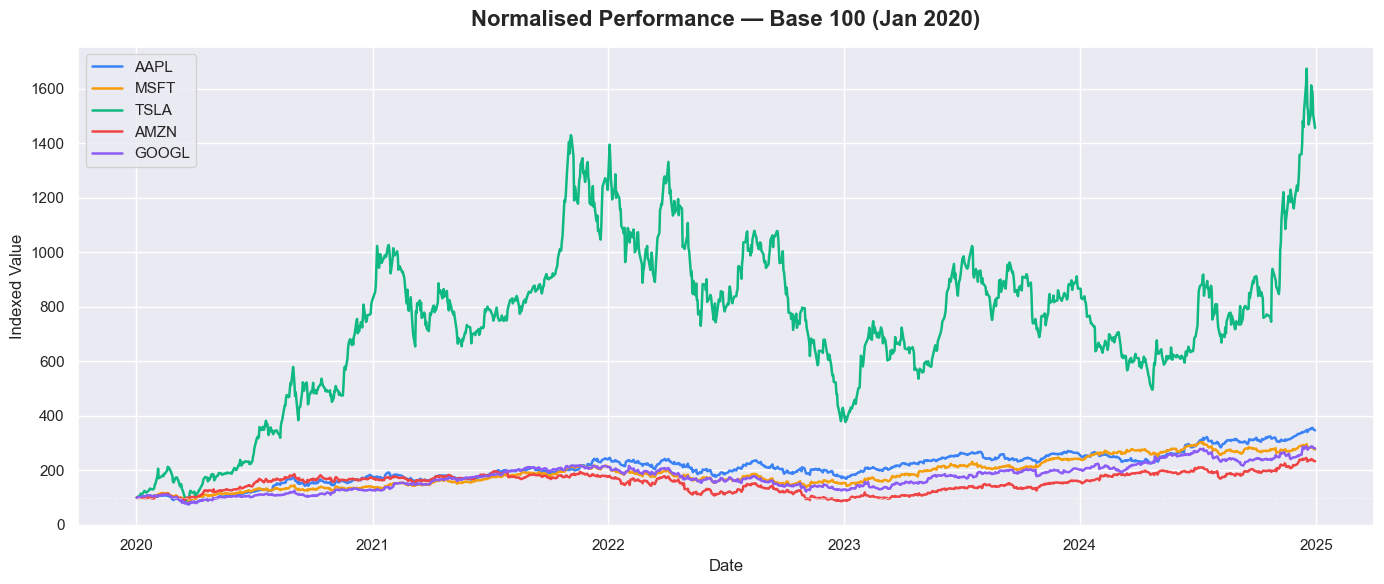

In [4]:
normalised = (df / df.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))
for ticker, color in zip(TICKERS, COLORS):
    ax.plot(normalised.index, normalised[ticker], label=ticker, color=color, linewidth=1.8)

ax.axhline(100, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Normalised Performance — Base 100 (Jan 2020)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Indexed Value')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('outputs/normalised_performance.png', dpi=150)
plt.show()

## 5. Moving Averages — Apple (AAPL)

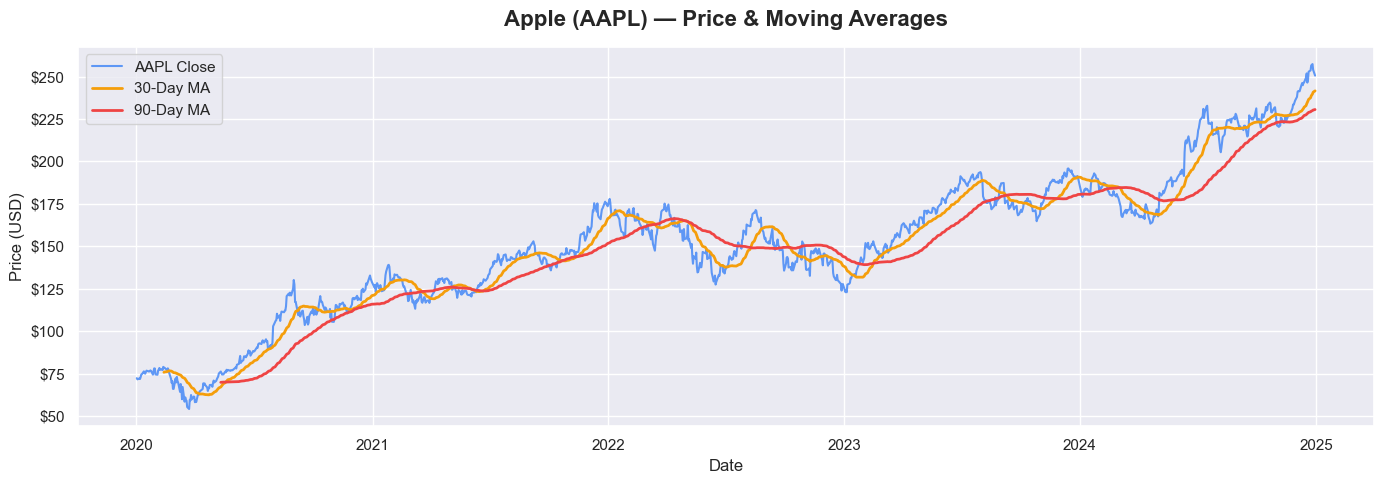

In [5]:
aapl = df[['AAPL']].copy()
aapl['MA_30']  = aapl['AAPL'].rolling(30).mean()
aapl['MA_90']  = aapl['AAPL'].rolling(90).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(aapl.index, aapl['AAPL'],  label='AAPL Close',  color='#3b82f6', linewidth=1.5, alpha=0.8)
ax.plot(aapl.index, aapl['MA_30'], label='30-Day MA',   color='#f59e0b', linewidth=2)
ax.plot(aapl.index, aapl['MA_90'], label='90-Day MA',   color='#ef4444', linewidth=2)

ax.set_title('Apple (AAPL) — Price & Moving Averages', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('outputs/aapl_moving_averages.png', dpi=150)
plt.show()

## 6. Daily Returns

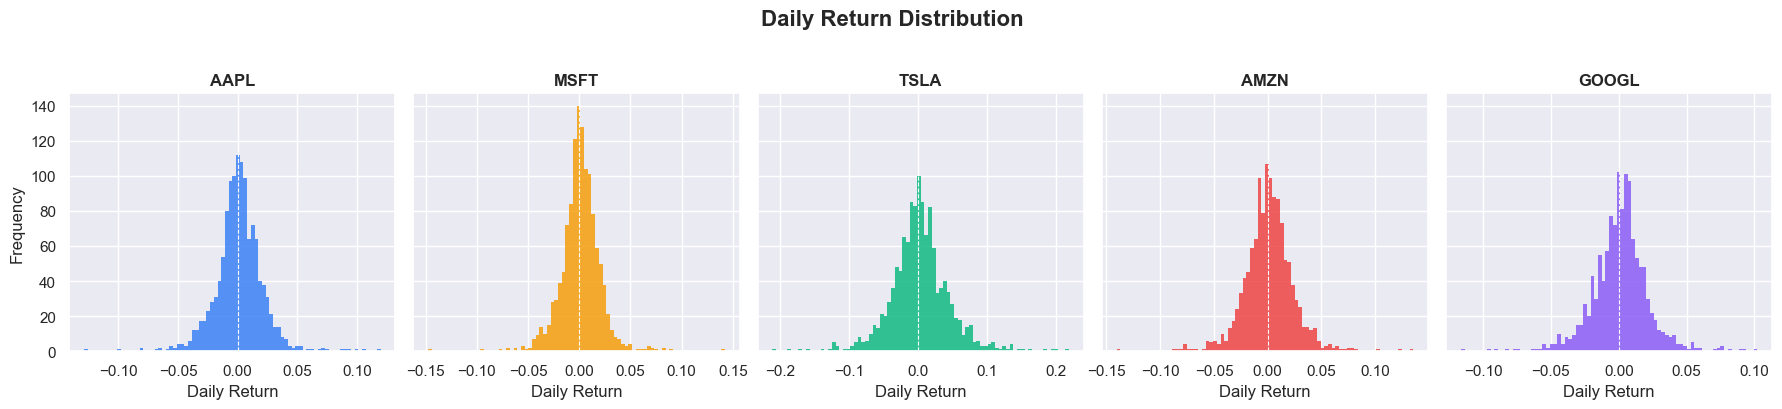

In [6]:
returns = df.pct_change().dropna()

fig, axes = plt.subplots(1, len(TICKERS), figsize=(18, 4), sharey=True)
for ax, ticker, color in zip(axes, TICKERS, COLORS):
    ax.hist(returns[ticker], bins=80, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(0, color='white', linestyle='--', linewidth=0.8)
    ax.set_title(ticker, fontweight='bold')
    ax.set_xlabel('Daily Return')

axes[0].set_ylabel('Frequency')
fig.suptitle('Daily Return Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/daily_returns.png', dpi=150)
plt.show()

## 7. Volatility (30-Day Rolling Std)

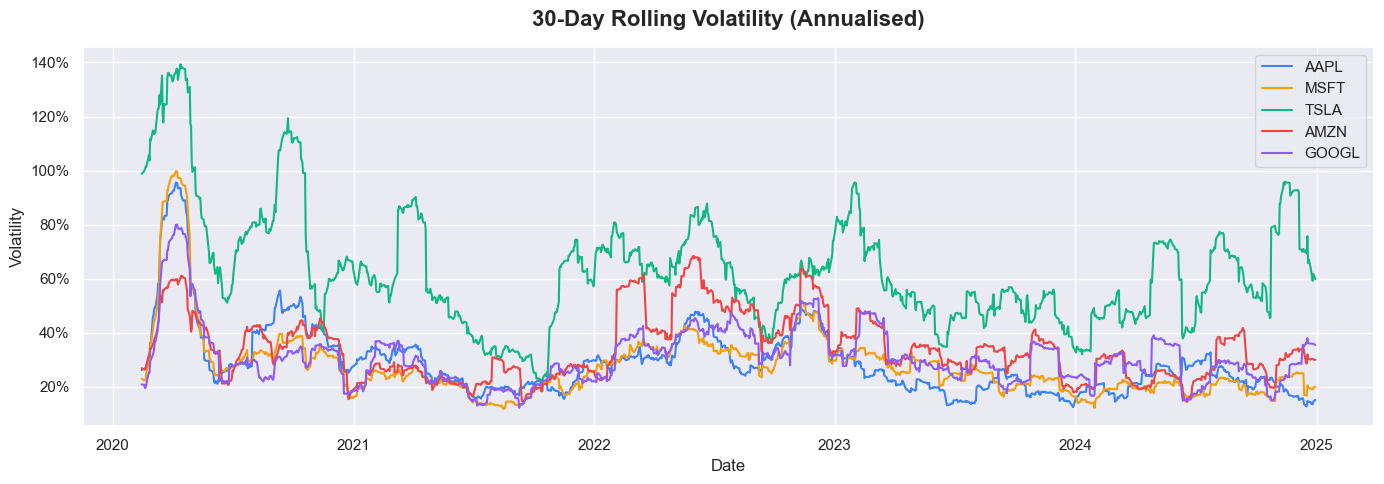

In [7]:
volatility = returns.rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))
for ticker, color in zip(TICKERS, COLORS):
    ax.plot(volatility.index, volatility[ticker], label=ticker, color=color, linewidth=1.5)

ax.set_title('30-Day Rolling Volatility (Annualised)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
plt.tight_layout()
plt.savefig('outputs/volatility.png', dpi=150)
plt.show()

## 8. Correlation Heatmap

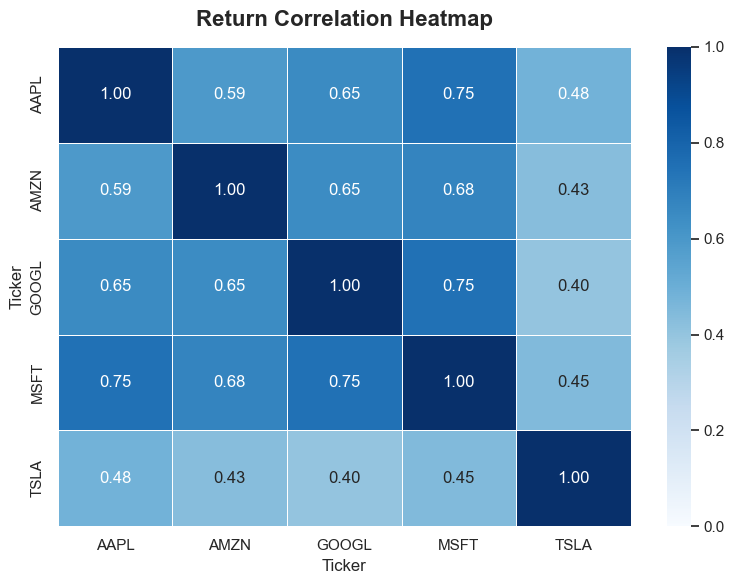

In [8]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='Blues',
    linewidths=0.5, ax=ax, vmin=0, vmax=1,
    annot_kws={'size': 12}
)
ax.set_title('Return Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150)
plt.show()

## 9. Key Statistics Summary

In [9]:
summary = pd.DataFrame({
    'Start Price ($)' : df.iloc[0].round(2),
    'End Price ($)'   : df.iloc[-1].round(2),
    'Total Return (%)':(((df.iloc[-1] / df.iloc[0]) - 1) * 100).round(2),
    'Avg Daily Return (%)' : (returns.mean() * 100).round(3),
    'Daily Volatility (%)' : (returns.std() * 100).round(3),
    'Max Price ($)'   : df.max().round(2),
    'Min Price ($)'   : df.min().round(2),
})

print('=' * 60)
print('           STOCKLENS — KEY STATISTICS')
print('=' * 60)
summary

           STOCKLENS — KEY STATISTICS


,Start Price ($),End Price ($),Total Return (%),Avg Daily Return (%),Daily Volatility (%),Max Price ($),Min Price ($)
Ticker,,,,,,,
AAPL,72.33,250.60,246.45,0.119,1.996,257.38,54.16
AMZN,94.90,221.30,133.19,0.093,2.266,232.93,81.82
GOOGL,67.87,190.36,180.46,0.103,2.048,195.76,52.27
MSFT,152.16,420.76,176.53,0.099,1.922,461.32,128.64
TSLA,28.68,417.41,1355.20,0.303,4.233,479.86,24.08


---
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · yfinance  
**Author:** Berke Arda Turk